## TS4 - Primeras nociones de estimación espectral

In [1]:
import numpy as np
import matplotlib.pyplot as plt

fs= 1000
N= 1000

a0= np.sqrt(2)      # potencia unitaria: Ps = a0^2/2 = 1 W
Omega0= np.pi / 2

SNR_dB= 10
sigma2= (a0**2 / 2) / 10**(SNR_dB/10)   # potencia del ruido = 1/10^(SNR/10)

np.random.seed(42)

fr= np.random.uniform(-2, 2)
Omega1= Omega0 + fr * (2*np.pi / N)

nn= np.arange(N) # indice de muestra

na= np.random.normal(0, np.sqrt(sigma2), N)
xx= a0 * np.sin(Omega1 * nn) + na

print(f'fr = {fr:.4f}   Omega1 = {Omega1:.6f} rad/muestra   f1 = {Omega1/(2*np.pi)*fs:.4f} Hz')

fr = -0.5018   Omega1 = 1.567643 rad/muestra   f1 = 249.4982 Hz


### Desparramo espectral

La DFT de una senoidal ventaneada con rectangular es el kernel de Dirichlet (la "sinc" periodica) centrado en $f_1$. Como $f_r \sim \mathcal{U}(-2,2)$ y $\Delta f = f_S/N$, el pico siempre cae dentro de la banda $f_0 \pm 2\Delta f$.

Para ver la forma de la sinc hay que interpolar la DTFT con zero-padding: la DFT de $N$ puntos solo la muestrea cada $\Delta f$, y en $\pm 2\Delta f$ eso son apenas 5 muestras.

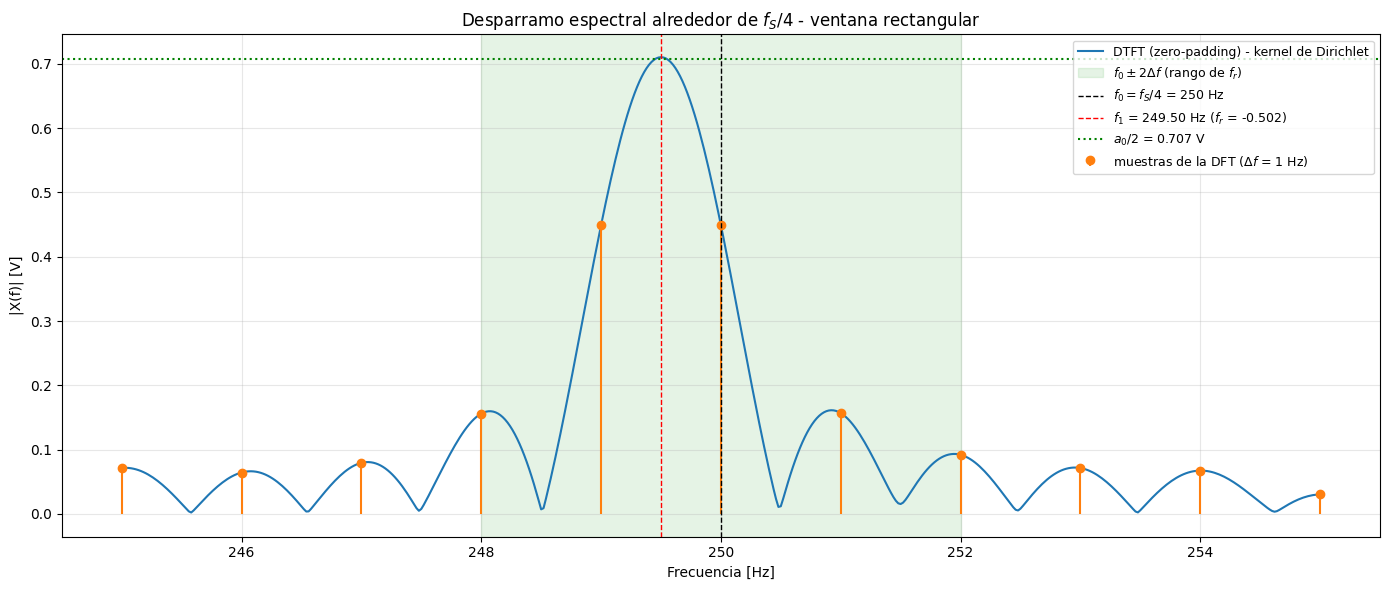

In [2]:
f0= fs / 4  # 250 Hz -> bin N/4
f1= Omega1 / (2*np.pi) * fs # frecuencia real, desintonizada
df= fs / N  # 1 Hz

# DTFT interpolada por zero-padding
Npad= 50 * N
ff_p= np.arange(Npad) * fs / Npad
XX_p= np.abs(np.fft.fft(xx, Npad)) / N

# DFT cruda: las muestras que realmente ve el estimador
ff_d= np.arange(N) * df
XX_d= np.abs(np.fft.fft(xx)) / N

# zoom de +/- 5 df alrededor de f0
mp= (ff_p >= f0 - 5*df) & (ff_p <= f0 + 5*df)
md_= (ff_d >= f0 - 5*df) & (ff_d <= f0 + 5*df)

plt.figure(figsize=(14, 6))
plt.plot(ff_p[mp], XX_p[mp], lw=1.5, label='DTFT (zero-padding) - kernel de Dirichlet')
plt.stem(ff_d[md_], XX_d[md_], linefmt='C1-', markerfmt='C1o', basefmt=' ',
         label='muestras de la DFT ($\\Delta f$ = 1 Hz)')

plt.axvspan(f0 - 2*df, f0 + 2*df, color='C2', alpha=0.12,
            label='$f_0 \\pm 2\\Delta f$ (rango de $f_r$)')
plt.axvline(f0, color='k', linestyle='--', lw=1, label=f'$f_0 = f_S/4$ = {f0:.0f} Hz')
plt.axvline(f1, color='r', linestyle='--', lw=1, label=f'$f_1$ = {f1:.2f} Hz ($f_r$ = {fr:.3f})')
plt.axhline(a0/2, color='g', linestyle=':', lw=1.5, label=f'$a_0/2$ = {a0/2:.3f} V')

plt.title('Desparramo espectral alrededor de $f_S/4$ - ventana rectangular')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('|X(f)| [V]')
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

### 200 realizaciones

Hasta aca trabajamos con una sola realizacion. Para poder estimar
amplitud y frecuencia hace falta una tanda de $R = 200$ experimentos, cada uno con su propio
$f_r \sim \mathcal{U}(-2,\,2)$ y su propio ruido.

Todo se arma de una sola vez como una matriz de $N \times R$, aprovechando *broadcasting*:

$$ \mathbf{X} = a_0 \cdot sen(\mathbf{n} \cdot \mathbf{\Omega_1}) + \mathbf{N_a} $$

donde $\mathbf{n}$ es un vector columna ($N \times 1$) y $\mathbf{\Omega_1}$ un vector fila
($1 \times R$). Cada columna es una realizacion distinta.

In [3]:
R= 200  # cantidad de realizaciones

np.random.seed(42)

# una fr distinta por realizacion -> vector fila (1 x R)
fr_v= np.random.uniform(-2, 2, size=(1, R)) # ya le da el formato matriz en el size
om1_v= Omega0 + fr_v * (2*np.pi / N) # 1 x R
f1_v= om1_v / (2*np.pi) * fs # frecuencia real de cada senoidal [Hz]

# indice de muestra como vector columna (N x 1) cambiar dimension de 0 a 1 para que deje de ser vector
nn_c= np.arange(N).reshape(N, 1)

# ruido independiente para cada realizacion (N x R)
Na= np.random.normal(0, np.sqrt(sigma2), size=(N, R))

# matriz de senales: cada COLUMNA es una realizacion
XX_M= a0 * np.sin(nn_c * om1_v) + Na # (N x 1) * (1 x R) -> N x R

print(f'XX_M.shape = {XX_M.shape}   (N muestras x R realizaciones)')
print(f'fr  en [{fr_v.min():.3f}, {fr_v.max():.3f}]')
print(f'f1  en [{f1_v.min():.3f}, {f1_v.max():.3f}] Hz   (f0 = {f0:.0f} Hz, df = {df:.0f} Hz)')

XX_M.shape = (1000, 200)   (N muestras x R realizaciones)
fr  en [-1.978, 1.948]
f1  en [248.022, 251.948] Hz   (f0 = 250 Hz, df = 1 Hz)


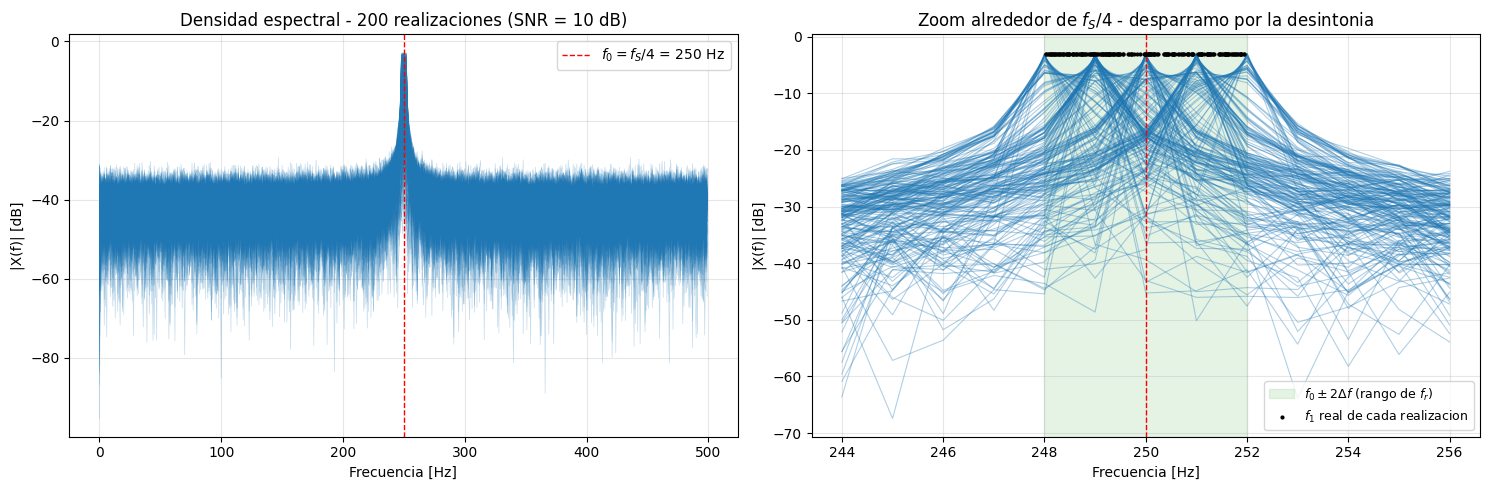

In [4]:
# DFT de todas las realizaciones de una: FFT por columnas, uso axis=0 por lo explicado en clase
ff= np.arange(N) * df
XF_M= np.fft.fft(XX_M, axis=0) / N
XF_dB= 20 * np.log10(np.abs(XF_M) + 1e-12)

bfr= N // 2  # solo media banda (hasta fs/2)

fig, ax= plt.subplots(1, 2, figsize=(15, 5))

# --- espectro completo: las 200 superpuestas ---
ax[0].plot(ff[:bfr], XF_dB[:bfr, :], lw=0.5, alpha=0.25, color='C0')
ax[0].axvline(f0, color='r', ls='--', lw=1, label=f'$f_0 = f_S/4$ = {f0:.0f} Hz')
ax[0].set_title(f'Densidad espectral - {R} realizaciones (SNR = {SNR_dB} dB)')
ax[0].set_xlabel('Frecuencia [Hz]')
ax[0].set_ylabel('|X(f)| [dB]')
ax[0].grid(True, alpha=0.3)
ax[0].legend()

# --- zoom en fs/4 ---
mz = (ff >= f0 - 6*df) & (ff <= f0 + 6*df)
ax[1].plot(ff[mz], XF_dB[mz, :], lw=0.8, alpha=0.35, color='C0')
ax[1].axvspan(f0 - 2*df, f0 + 2*df, color='C2', alpha=0.12,
              label='$f_0 \\pm 2\\Delta f$ (rango de $f_r$)')
ax[1].axvline(f0, color='r', ls='--', lw=1)
ax[1].plot(f1_v.ravel(), np.full(R, 20*np.log10(a0/2)), 'k.', ms=4,
           label='$f_1$ real de cada realizacion')
ax[1].set_title('Zoom alrededor de $f_S/4$ - desparramo por la desintonia')
ax[1].set_xlabel('Frecuencia [Hz]')
ax[1].set_ylabel('|X(f)| [dB]')
ax[1].grid(True, alpha=0.3)
ax[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

### Estimacion con ventanas

Para cada una de las ventanas rectangular (sin ventana), flattop, Blackman-Harris y Hann se multiplica cada realizacion por la ventana $w(n)$ y se calculan dos estimadores:

$$ \hat{a}_1 = \frac{2\,|X_w(\Omega_0)|}{\sum_n w(n)} $$

(amplitud leida en el bin fijo $k_0 = N/4$. Dividir por $\sum w$ compensa la ganancia coherente de cada ventana, asi con $f_r = 0$ y sin ruido da exactamente $a_0$)

$$ \hat{\Omega}_1 = \frac{2\pi}{N}\,\underset{k}{\arg\max}\,\{|X_w[k]|\} $$

Con las $R = 200$ realizaciones se estiman sesgo y varianza:

$$ s_a = \overline{\hat a_1} - a_0 \qquad v_a = \frac{1}{R}\sum_{j=1}^{R}\left(\hat a_{1,j} - \overline{\hat a_1}\right)^2 $$

$$ s_\Omega = \overline{\hat\Omega_{1,j} - \Omega_{1,j}} \qquad v_\Omega = \mathrm{var}\{\hat\Omega_{1,j} - \Omega_{1,j}\} $$

En frecuencia se compara contra el $\Omega_1$ real de cada realizacion, porque cambia de una a otra.

Antes de estimar conviene mirar el espectro de cada ventana: como $\hat a_1$ se lee siempre en $k_0$ y la senoidal esta corrida $f_r$ bins, el valor de la curva en $f_r$ es la atenuacion que sufre el estimador de amplitud. La franja verde es todo el rango posible de $f_r$.

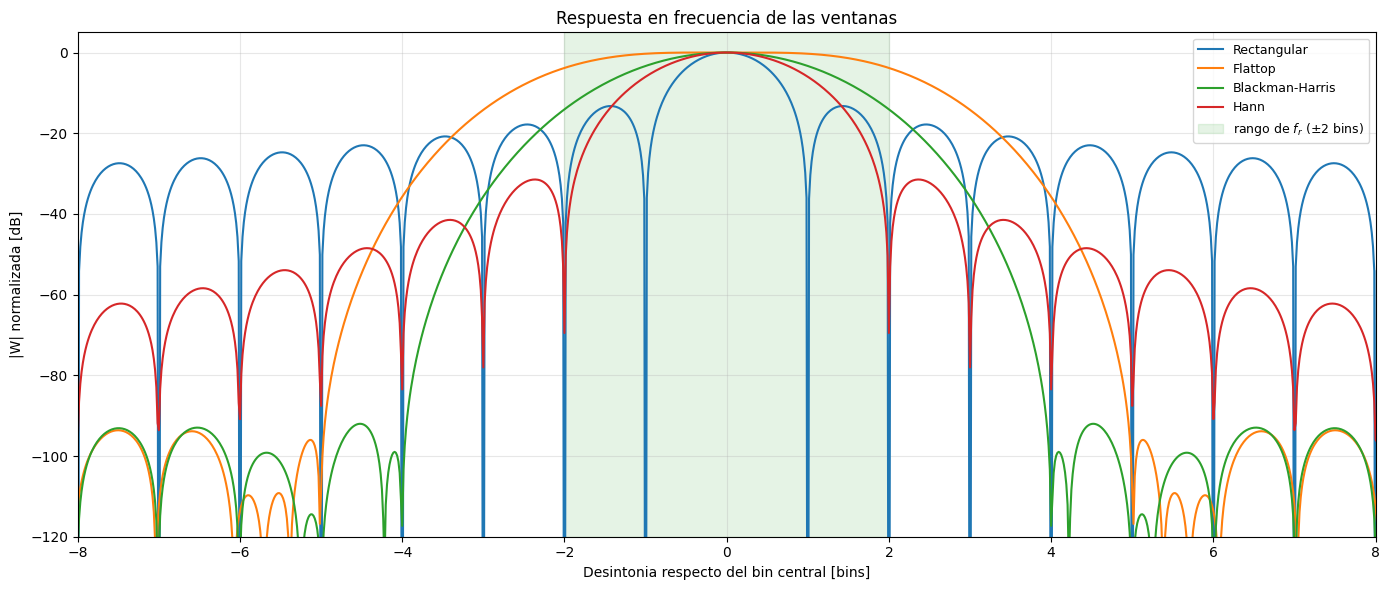

In [5]:
from scipy.signal import windows as win

ventanas = {
    'Rectangular':     win.boxcar(N),
    'Flattop':         win.flattop(N),
    'Blackman-Harris': win.blackmanharris(N),
    'Hann':            win.hann(N),
}

# espectro de cada ventana con mucho zero-padding, normalizado a 0 dB en el pico
Npad_w= 64 * N
bins_w= np.fft.fftshift(np.fft.fftfreq(Npad_w, d=1/N))  # eje en bins (multiplos de df)

plt.figure(figsize=(14, 6))
for nombre, w in ventanas.items():
    W= np.fft.fftshift(np.abs(np.fft.fft(w, Npad_w)))
    plt.plot(bins_w, 20*np.log10(W / W.max() + 1e-12), lw=1.5, label=nombre)

plt.axvspan(-2, 2, color='C2', alpha=0.12, label='rango de $f_r$ ($\\pm 2$ bins)')
plt.title('Respuesta en frecuencia de las ventanas')
plt.xlabel('Desintonia respecto del bin central [bins]')
plt.ylabel('|W| normalizada [dB]')
plt.xlim(-8, 8)
plt.ylim(-120, 5)
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

In [6]:
def generar_tanda(SNR_dB, R=200, seed=42):
    """Matriz N x R de realizaciones (misma receta que arriba) y el Omega1 real de cada una."""
    np.random.seed(seed)
    sigma2= (a0**2 / 2) / 10**(SNR_dB/10)
    fr_v= np.random.uniform(-2, 2, size=(1, R))
    om1_v= Omega0 + fr_v * (2*np.pi / N)
    Na= np.random.normal(0, np.sqrt(sigma2), size=(N, R))
    return a0 * np.sin(nn_c * om1_v) + Na, om1_v.ravel()


def estimar(XX, w):
    """Estimadores de amplitud y frecuencia para todas las columnas de XX con la ventana w."""
    Xw= np.fft.fft(XX * w.reshape(N, 1), axis=0)  # ventaneo por broadcasting: (N x R) * (N x 1)
    k0= N // 4   # bin de Omega0 = pi/2
    a_est = 2 * np.abs(Xw[k0, :]) / np.sum(w)
    om_est= np.argmax(np.abs(Xw[:N//2, :]), axis=0) * 2*np.pi / N
    return a_est, om_est


SNRs= [3, 10]  # lo dejo en dB
resultados = {}

for snr in SNRs:
    XX, om1 = generar_tanda(snr, R)
    for nombre, w in ventanas.items():
        a_est, om_est = estimar(XX, w)
        err_om = om_est - om1 # error contra el Omega1 real de cada realizacion
        resultados[(snr, nombre)] = dict(
            a_est=a_est, err_om=err_om,
            sa=np.mean(a_est) - a0, va=np.var(a_est),
            so=np.mean(err_om),     vo=np.var(err_om))

### 1) Histogramas de los estimadores

Para cada SNR se superponen las 4 ventanas en un mismo histograma: a la izquierda el estimador de amplitud $\hat a_1$ y a la derecha el error del estimador de frecuencia $\hat\Omega_1 - \Omega_1$ (en bins, para que se lea directamente como fraccion de $\Delta f$).

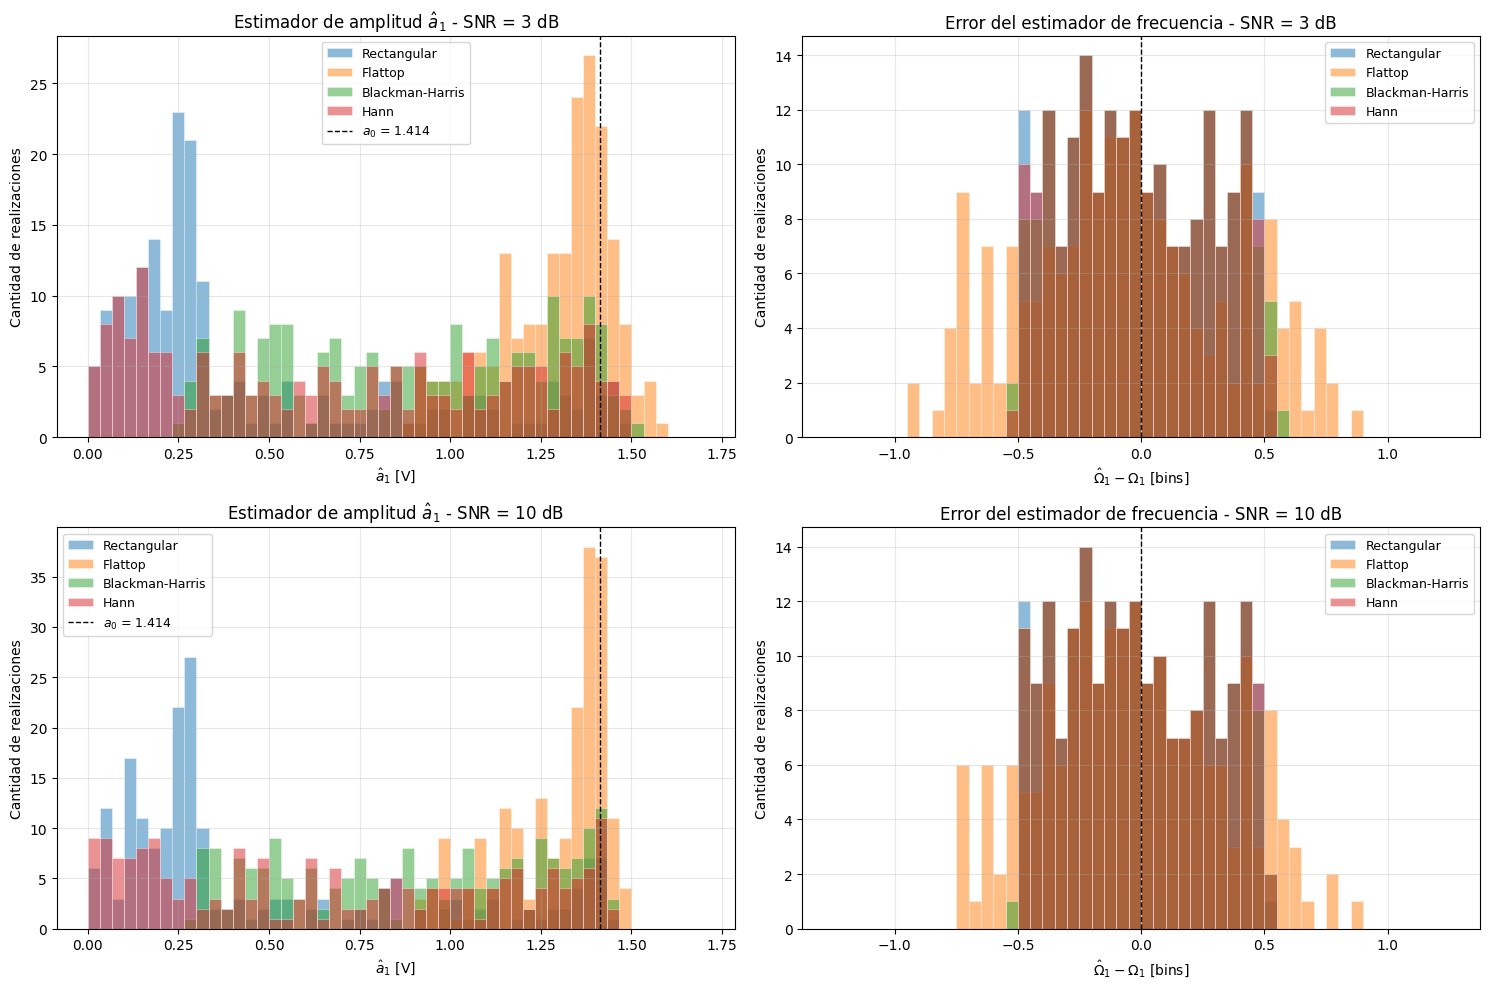

In [7]:
bins_a= np.linspace(0, 1.7, 52)
bins_o= np.arange(-1.25, 1.30, 0.05)  # error de frecuencia en bins
estilo= dict(alpha=0.5, edgecolor='white', linewidth=0.5)

fig, ax= plt.subplots(len(SNRs), 2, figsize=(15, 5*len(SNRs)))

for i, snr in enumerate(SNRs):
    for nombre in ventanas:
        r = resultados[(snr, nombre)]
        ax[i, 0].hist(r['a_est'], bins=bins_a, label=nombre, **estilo)
        ax[i, 1].hist(r['err_om'] * N/(2*np.pi), bins=bins_o, label=nombre, **estilo)

    ax[i, 0].axvline(a0, color='k', ls='--', lw=1, label=f'$a_0$ = {a0:.3f}')
    ax[i, 0].set_title(f'Estimador de amplitud $\\hat a_1$ - SNR = {snr} dB')
    ax[i, 0].set_xlabel('$\\hat a_1$ [V]')

    ax[i, 1].axvline(0, color='k', ls='--', lw=1)
    ax[i, 1].set_title(f'Error del estimador de frecuencia - SNR = {snr} dB')
    ax[i, 1].set_xlabel('$\\hat\\Omega_1 - \\Omega_1$ [bins]')

    for a in ax[i]:
        a.set_ylabel('Cantidad de realizaciones')
        a.grid(True, alpha=0.3)
        a.legend(fontsize=9)

plt.tight_layout()
plt.show()

### 2) Tablas de sesgo y varianza

El sesgo y la varianza de frecuencia se expresan en **bins** ($1$ bin $= \frac{2\pi}{N}$ rad/muestra $= \Delta f = 1$ Hz), que es la unidad natural del problema: tanto la desintonia $f_r$ como la resolucion de la DFT se miden en bins.

In [8]:
b= N / (2*np.pi)  # rad/muestra -> bins (1 bin = 2pi/N rad/muestra)

for snr in SNRs:
    print(f'\nSNR = {snr} dB   (a0 = {a0:.4f} V, R = {R} realizaciones)')
    print(f'{"Ventana":<16} | {"s_a [V]":>9} | {"v_a [V^2]":>9} | {"s_Omega [bins]":>14} | {"v_Omega [bins^2]":>16}')
    print('-' * 76)
    for nombre in ventanas:
        r = resultados[(snr, nombre)]
        print(f'{nombre:<16} | {r["sa"]:>+9.4f} | {r["va"]:>9.2e} | {r["so"]*b:>+14.4f} | {r["vo"]*b**2:>16.4f}')


SNR = 3 dB   (a0 = 1.4142 V, R = 200 realizaciones)
Ventana          |   s_a [V] | v_a [V^2] | s_Omega [bins] | v_Omega [bins^2]
----------------------------------------------------------------------------
Rectangular      |   -0.9336 |  1.90e-01 |        -0.0160 |           0.0838
Flattop          |   -0.1248 |  2.51e-02 |        -0.0660 |           0.1719
Blackman-Harris  |   -0.5095 |  1.33e-01 |        -0.0010 |           0.0859
Hann             |   -0.7244 |  2.22e-01 |        -0.0110 |           0.0842

SNR = 10 dB   (a0 = 1.4142 V, R = 200 realizaciones)
Ventana          |   s_a [V] | v_a [V^2] | s_Omega [bins] | v_Omega [bins^2]
----------------------------------------------------------------------------
Rectangular      |   -0.9364 |  1.89e-01 |        -0.0160 |           0.0838
Flattop          |   -0.1253 |  2.16e-02 |        -0.0310 |           0.1295
Blackman-Harris  |   -0.5109 |  1.31e-01 |        -0.0160 |           0.0840
Hann             |   -0.7290 |  2.24e-01 |    

### Análisis de resultados

#### Estimador de amplitud

Como $\hat a_1$ se toma siempre en un bin fijo, el resultado depende de cuánto atenúa cada ventana a la frecuencia real. Como $f_r$ recorre un rango de $\pm 2$ bins, se puede resumir así:

| Ventana | Atenuación en $f_r = \pm 1$ | Atenuación en $f_r = \pm 2$ |
|---|---|---|
| Rectangular | nulo | nulo |
| Hann | -6 dB | ~nulo (-70 dB) |
| Blackman-Harris | -3.3 dB | -14 dB |
| Flattop | -0.3 dB | -3.8 dB |

La rectangular presenta el mayor error porque atenúa mucho cuando la frecuencia se aleja del bin elegido. Hann y Blackman-Harris mejoran este comportamiento, mientras que la flattop es la que mantiene mejor la amplitud en todo el rango.

Entre 3 y 10 dB de SNR los resultados cambian poco, por lo que el error está dominado principalmente por la desintonía y no por el ruido. En la flattop el ruido tiene algo más de influencia debido a su mayor ancho de banda.

#### Estimador de frecuencia

Para la frecuencia, la rectangular, Hann y Blackman-Harris presentan resultados muy similares. El principal límite es la separación entre los puntos de la DFT, por lo que el error depende principalmente de la resolución del espectro.

La flattop presenta peores resultados porque su pico es más plano y resulta más difícil determinar exactamente dónde está el máximo, especialmente cuando hay ruido.

En conclusión, la flattop es la más adecuada para estimar amplitud, mientras que rectangular, Hann y Blackman-Harris tienen un comportamiento similar para frecuencia. Para mejorar la estimación de frecuencia resulta más útil aumentar la cantidad de puntos del espectro o utilizar interpolación.

## Bonus - Efecto del zero-padding sobre $\hat\Omega_1$

El $\arg\max$ solo puede elegir una frecuencia de los puntos disponibles en la DFT. Por eso, aunque no hubiera ruido, existe un pequeño error debido a la separación entre esos puntos.

Al agregar ceros se agregan más puntos al espectro y la grilla se vuelve más fina. Esto permite encontrar con mayor precisión la posición de un pico aislado.

Es importante aclarar que el zero-padding no aumenta la resolución real del espectro: no permite distinguir dos frecuencias que antes estaban demasiado cerca. Simplemente mejora la precisión con la que se puede ubicar un pico.

In [9]:
def estimar_om_zp(XX, w, gamma):
    """argmax sobre la DTFT interpolada con zero-padding a NFFT = gamma*N."""
    NFFT= gamma * N
    Xw= np.fft.rfft(XX * w.reshape(N, 1), n=NFFT, axis=0)   # rfft: solo media banda
    return np.argmax(np.abs(Xw), axis=0) * 2*np.pi / NFFT


gammas= [1, 2, 4, 8, 16, 32]
zp = {}

for snr in SNRs:
    XX, om1= generar_tanda(snr, R) # misma tanda que en el experimento principal
    for nombre, w in ventanas.items():
        for g in gammas:
            err_om = (estimar_om_zp(XX, w, g) - om1) * b   # error en bins
            zp[(snr, nombre, g)] = np.var(err_om)

for snr in SNRs:
    print(f'\nv_Omega [bins^2] vs. factor de zero-padding   (SNR = {snr} dB)')
    print(f'{"Ventana":<16} |' + ''.join(f'{str(g)+"x":>11}' for g in gammas))
    print('-' * (18 + 11*len(gammas)))
    for nombre in ventanas:
        print(f'{nombre:<16} |' + ''.join(f'{zp[(snr, nombre, g)]:>11.2e}' for g in gammas))

print(f'\nPiso de cuantizacion sin zero-padding: 1/12 = {1/12:.4f} bins^2')


v_Omega [bins^2] vs. factor de zero-padding   (SNR = 3 dB)
Ventana          |         1x         2x         4x         8x        16x        32x
------------------------------------------------------------------------------------
Rectangular      |   8.38e-02   2.08e-02   5.19e-03   1.43e-03   4.97e-04   2.44e-04
Flattop          |   1.72e-01   2.27e-01   2.16e-01   2.20e-01   2.24e-01   2.25e-01
Blackman-Harris  |   8.59e-02   2.12e-02   5.32e-03   1.98e-03   1.22e-03   7.94e-04
Hann             |   8.42e-02   2.11e-02   5.16e-03   1.62e-03   7.34e-04   4.52e-04

v_Omega [bins^2] vs. factor de zero-padding   (SNR = 10 dB)
Ventana          |         1x         2x         4x         8x        16x        32x
------------------------------------------------------------------------------------
Rectangular      |   8.38e-02   2.07e-02   5.03e-03   1.34e-03   3.76e-04   1.29e-04
Flattop          |   1.29e-01   1.33e-01   1.53e-01   1.53e-01   1.55e-01   1.56e-01
Blackman-Harris  |   8.40e-02

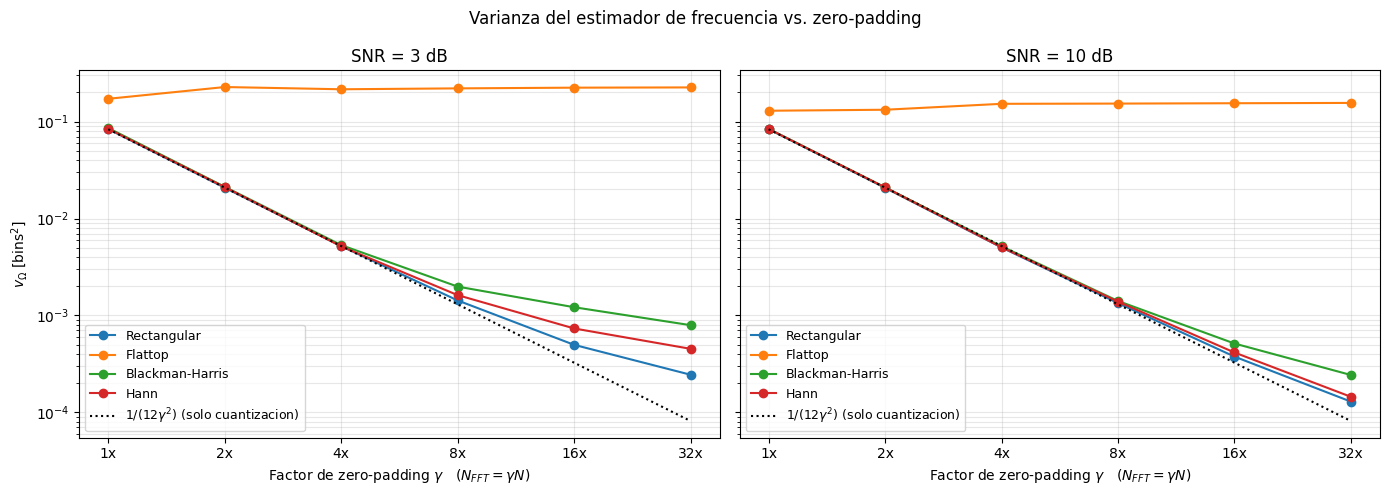

In [10]:
fig, ax= plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for i, snr in enumerate(SNRs):
    for nombre in ventanas:
        ax[i].plot(gammas, [zp[(snr, nombre, g)] for g in gammas], marker='o', label=nombre)

    # ley teorica de cuantizacion: 1/(12*gamma^2)
    ax[i].plot(gammas, [1/(12*g**2) for g in gammas], 'k:', lw=1.5,
               label='$1/(12\\gamma^2)$ (solo cuantizacion)')

    ax[i].set_xscale('log', base=2)
    ax[i].set_yscale('log')
    ax[i].set_xticks(gammas)
    ax[i].set_xticklabels([f'{g}x' for g in gammas])
    ax[i].set_title(f'SNR = {snr} dB')
    ax[i].set_xlabel('Factor de zero-padding $\\gamma$   ($N_{FFT} = \\gamma N$)')
    ax[i].grid(True, which='both', alpha=0.3)
    ax[i].legend(fontsize=9)

ax[0].set_ylabel('$v_\\Omega$ [bins$^2$]')
fig.suptitle('Varianza del estimador de frecuencia vs. zero-padding')
plt.tight_layout()
plt.show()

Rectangular, Hann y Blackman-Harris mejoran bastante al aumentar el zero-padding. Hasta cierto punto, cada vez que se duplica la cantidad de puntos de la FFT, la varianza se reduce aproximadamente 4 veces. A partir de $\gamma \approx 8$, la mejora empieza a ser menor porque el ruido comienza a tener más influencia.

En cambio, la flattop prácticamente no mejora con el zero-padding. Esto se debe a que su forma es más plana y el ruido influye en la posición donde se encuentra el máximo.

Zero-padding es útil principalmente cuando el problema está en la poca cantidad de puntos del espectro. Si la limitación viene del ruido o de la propia ventana, agregar más puntos no produce una mejora significativa.